# CoT causal alignment


## Deterministic reasoning trajectory

Generate one deterministic clean trajectory and inspect its token positions.


In [1]:
import random

import numpy as np
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

SEED = 0
MODEL_NAME = "Qwen/Qwen3-0.6B"
MAX_NEW_TOKENS = 500

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype="auto",
    device_map="auto",
)
model.eval()

messages = [{
    "role": "user",
    "content": """Alice is older than Bob.
Bob is older than Charlie.

Who is the oldest?
Explain your reasoning and give the final answer.""",
}]

prompt = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=True,
)
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

with torch.inference_mode():
    output_ids = model.generate(
        **inputs,
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )

prompt_length = inputs["input_ids"].shape[-1]
generated_ids = output_ids[0, prompt_length:]
trajectory = tokenizer.decode(generated_ids, skip_special_tokens=False)
generated_tokens = tokenizer.convert_ids_to_tokens(generated_ids.tolist())

print(f"model={MODEL_NAME} seed={SEED} do_sample=False max_new_tokens={MAX_NEW_TOKENS}")
print("\n=== COMPLETE GENERATED TRAJECTORY ===")
print(trajectory)
print("\n=== GENERATED TOKEN POSITIONS ===")
for position, token in enumerate(generated_tokens):
    print(f"{position:03d}\t{token!r}")

  Preparing metadata (setup.py) ... done
... saved output shortened ...
ist-packages (from typer->transformers>=5.9.0->transformer-lens) (1.5.4)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 29.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 5.9 MB/s eta 0:00:00
  Created wheel for transformers-stream-generator: filename=transformers_stream_generator-0.0.5-py3-none-any.whl size=12426 sha256=a05e8fa3e4d1fe3d9c9e5826ee25d7203cf947da9c4a0a7247e4ba76945125bb
  Stored in directory: /root/.cache/pip/wheels/f6/6e/1a/710143d0e50e827ae5b60a47a6d43d715cf1c6e35881a05530
Successfully built transformers-stream-generator


model=Qwen/Qwen3-0.6B seed=0 do_sample=False max_new_tokens=500

=== COMPLETE GENERATED TRAJECTORY ===
<think>
Okay, let's see. The problem says Alice is older than Bob, and Bob is older than Charlie. I need to figure out who is the oldest among them. Hmm, so first, I should probably list out the relationships.

So, Alice > Bob, and Bob > Charlie. That means starting from the top, Alice is the oldest, then Bob, then Charlie. So if I imagine a line of ages, Alice is first, Bob second, and Charlie third. Therefore, the oldest would be Alice. But wait, maybe there's something else I'm missing? Like, could there be a case where someone is older than both? But according to the given statements, Alice is older than Bob, and Bob is older than Charlie. So there's no overlap in their ages beyond those two. So Alice must be the oldest. 

Wait, but maybe there's a trick here. Like, if they are all in a group, but the problem doesn't mention any other people. So the answer should be Alice. Let me 

## Semantic checkpoints

Map repeated reasoning events before selecting checkpoints.


In [2]:
event_candidates = {
    "Premise restatement": [
        (11, 22),
        (51, 58),
        (139, 150),
        (214, 220),
    ],
    "Integrated relation": [
        (51, 76),
        (87, 96),
        (214, 230),
    ],
    "Decision": [
        (67, 70),
        (98, 104),
        (164, 169),
        (202, 207),
        (231, 236),
    ],
}

think_end = generated_tokens.index("</think>")
for event_name, candidates in event_candidates.items():
    for candidate_number, (start, end) in enumerate(candidates, start=1):
        assert 0 <= start <= end < think_end
        span_text = tokenizer.decode(generated_ids[start:end + 1], skip_special_tokens=False)
        print(f"{event_name} — candidate {candidate_number}")
        print(f"start={start}, end={end}")
        print(span_text)
        print()

Premise restatement — candidate 1
start=11, end=22
 Alice is older than Bob, and Bob is older than Charlie

Premise restatement — candidate 2
start=51, end=58
 Alice > Bob, and Bob > Charlie

Premise restatement — candidate 3
start=139, end=150
 Alice is older than Bob, and Bob is older than Charlie

Premise restatement — candidate 4
start=214, end=220
 Alice > Bob, Bob > Charlie

Integrated relation — candidate 1
start=51, end=76
 Alice > Bob, and Bob > Charlie. That means starting from the top, Alice is the oldest, then Bob, then Charlie

Integrated relation — candidate 2
start=87, end=96
 Alice is first, Bob second, and Charlie third

Integrated relation — candidate 3
start=214, end=230
 Alice > Bob, Bob > Charlie. So yes, Alice is older than both.

Decision — candidate 1
start=67, end=70
 Alice is the oldest

Decision — candidate 2
start=98, end=104
 Therefore, the oldest would be Alice

Decision — candidate 3
start=164, end=169
 So Alice must be the oldest

Decision — candidate 4


## Answer preference through reasoning

Measure the Alice-Bob next-token logit difference along the clean trajectory; local context makes this non-causal readout unstable.


Premise restatement: before start t=10, D_t=11.687500
Premise restatement: end t=22, D_t=-1.859375
Integrated relation: before start t=50, D_t=10.125000
Integrated relation: end t=58, D_t=0.812500
Decision: before start t=66, D_t=7.000000
Decision: end t=70, D_t=0.875000


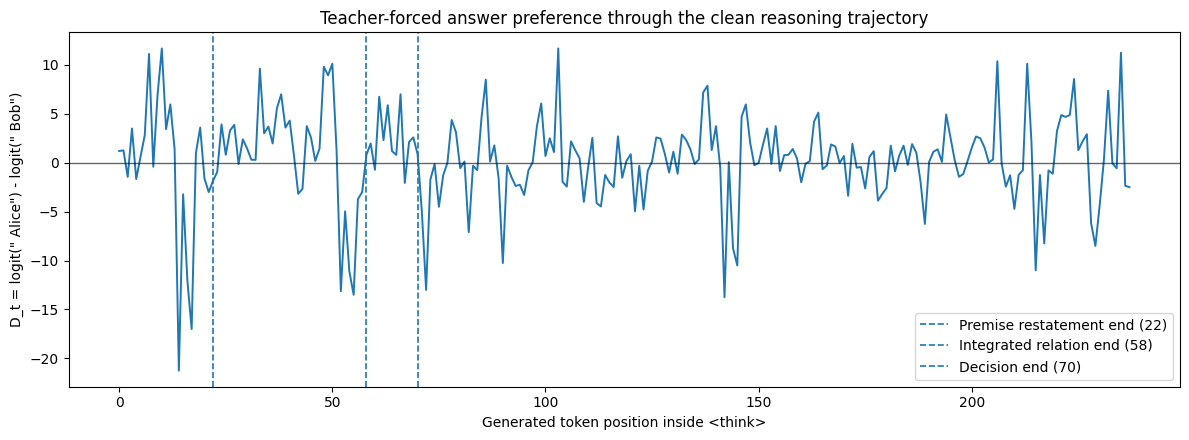

In [3]:
import matplotlib.pyplot as plt

selected_checkpoints = {
    "Premise restatement": (11, 22),
    "Integrated relation": (51, 58),
    "Decision": (67, 70),
}

alice_ids = tokenizer.encode(" Alice", add_special_tokens=False)
bob_ids = tokenizer.encode(" Bob", add_special_tokens=False)
assert len(alice_ids) == len(bob_ids) == 1
alice_token_id, bob_token_id = alice_ids[0], bob_ids[0]

with torch.inference_mode():
    teacher_forced_logits = model(output_ids).logits[0]

reasoning_positions = list(range(think_end))
sequence_positions = torch.arange(
    prompt_length, prompt_length + think_end, device=teacher_forced_logits.device
)
answer_preference = (
    teacher_forced_logits[sequence_positions, alice_token_id]
    - teacher_forced_logits[sequence_positions, bob_token_id]
).float().cpu()

for event_name, (start, end) in selected_checkpoints.items():
    before = start - 1
    print(f"{event_name}: before start t={before}, D_t={answer_preference[before].item():.6f}")
    print(f"{event_name}: end t={end}, D_t={answer_preference[end].item():.6f}")

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(reasoning_positions, answer_preference.numpy(), linewidth=1.4)
ax.axhline(0.0, color="black", linewidth=1, alpha=0.6)
for event_name, (_, end) in selected_checkpoints.items():
    ax.axvline(end, linestyle="--", linewidth=1.2, label=f"{event_name} end ({end})")
ax.set_xlabel("Generated token position inside <think>")
ax.set_ylabel('D_t = logit(" Alice") - logit(" Bob")')
ax.set_title("Teacher-forced answer preference through the clean reasoning trajectory")
ax.legend()
plt.tight_layout()
plt.show()

## Final-answer readout

Measure the Alice-Bob logit difference immediately before the answer.


In [4]:
final_answer_token_position = 281
readout_position = final_answer_token_position - 1
assert tokenizer.decode(generated_ids[final_answer_token_position:final_answer_token_position + 1]) == " Alice"

sequence_readout_position = prompt_length + readout_position
alice_logit = teacher_forced_logits[sequence_readout_position, alice_token_id].item()
bob_logit = teacher_forced_logits[sequence_readout_position, bob_token_id].item()
surrounding_text = tokenizer.decode(
    generated_ids[max(0, readout_position - 8):min(len(generated_ids), final_answer_token_position + 2)],
    skip_special_tokens=False,
)

print(f"Generated-token readout position: {readout_position}")
print(f"Surrounding text: {surrounding_text!r}")
print(f'logit(" Alice"): {alice_logit:.6f}')
print(f'logit(" Bob"): {bob_logit:.6f}')
print(f"D: {alice_logit - bob_logit:.6f}")

Generated-token readout position: 280
Surrounding text: ' is **Alice**.\n\n**Final Answer:** Alice.'
logit(" Alice"): 25.750000
logit(" Bob"): 11.875000
D: 13.875000


## Checkpoint-to-answer patching

Patch checkpoint states into the final-answer position. This cross-position intervention is exploratory.


Loaded pretrained model Qwen/Qwen3-0.6B into HookedTransformer
Unpatched final-readout baseline D: 13.701447

D_patch by checkpoint and layer:
layer                      0         1         2         3         4         5         6         7         8         9        10       11        12        13        14        15        16        17        18        19       20        21        22        23        24        25        26        27
checkpoint                                                                                                                                                                                                                                                                                              
Premise restatement -0.476101 -0.703022 -1.217899 -1.258228 -1.932570 -2.104782 -2.156982 -1.992729 -1.254498 -0.761508 0.532109 0.370440 -0.150586  0.418951  0.521861 -0.408144 -0.759926 -0.216692 -1.432829 -0.316592 0.748645 -0.663202 -2.254642 -1.942726 -1.986

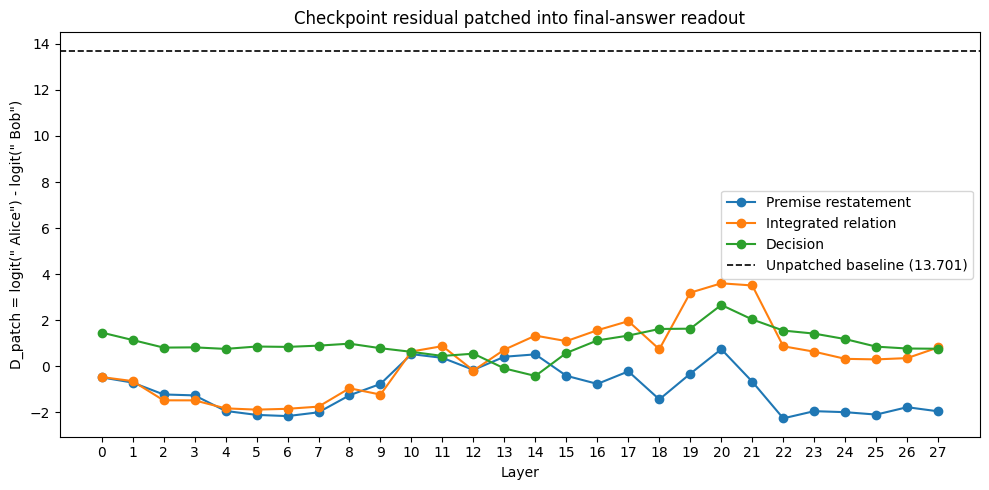

In [5]:
import pandas as pd
from transformer_lens import HookedTransformer

tl_model = HookedTransformer.from_pretrained(MODEL_NAME)
tl_model.eval()

checkpoint_ends = {
    "Premise restatement": 22,
    "Integrated relation": 58,
    "Decision": 70,
}
full_tokens = output_ids.to(tl_model.cfg.device)
readout_sequence_position = prompt_length + readout_position
checkpoint_sequence_positions = {
    name: prompt_length + position for name, position in checkpoint_ends.items()
}
tl_alice_token_id = tl_model.to_single_token(" Alice")
tl_bob_token_id = tl_model.to_single_token(" Bob")
assert tl_alice_token_id == alice_token_id
assert tl_bob_token_id == bob_token_id
assert full_tokens[0, readout_sequence_position + 1].item() == tl_alice_token_id

with torch.inference_mode():
    baseline_logits, clean_resid_cache = tl_model.run_with_cache(
        full_tokens,
        names_filter=lambda name: name.endswith("hook_resid_post"),
    )

baseline_D = (
    baseline_logits[0, readout_sequence_position, tl_alice_token_id]
    - baseline_logits[0, readout_sequence_position, tl_bob_token_id]
).item()

patch_rows = []
with torch.inference_mode():
    for checkpoint_name, checkpoint_position in checkpoint_sequence_positions.items():
        for layer in range(tl_model.cfg.n_layers):
            hook_name = f"blocks.{layer}.hook_resid_post"
            source_vector = clean_resid_cache[hook_name][0, checkpoint_position].detach().clone()

            def patch_checkpoint_into_readout(activation, hook, source=source_vector):
                patched = activation.clone()
                patched[0, readout_sequence_position] = source
                return patched

            patched_logits = tl_model.run_with_hooks(
                full_tokens,
                fwd_hooks=[(hook_name, patch_checkpoint_into_readout)],
            )
            D_patch = (
                patched_logits[0, readout_sequence_position, tl_alice_token_id]
                - patched_logits[0, readout_sequence_position, tl_bob_token_id]
            ).item()
            patch_rows.append({
                "checkpoint": checkpoint_name,
                "layer": layer,
                "D_patch": D_patch,
            })

patch_results = pd.DataFrame(patch_rows)
patch_table = patch_results.pivot(index="checkpoint", columns="layer", values="D_patch").loc[
    list(checkpoint_ends)
]
print(f"Unpatched final-readout baseline D: {baseline_D:.6f}")
print("\nD_patch by checkpoint and layer:")
print(patch_table.to_string(float_format=lambda value: f"{value:.6f}"))

fig, ax = plt.subplots(figsize=(10, 5))
for checkpoint_name in checkpoint_ends:
    checkpoint_results = patch_results[patch_results["checkpoint"] == checkpoint_name]
    ax.plot(checkpoint_results["layer"], checkpoint_results["D_patch"], marker="o", label=checkpoint_name)
ax.axhline(baseline_D, color="black", linestyle="--", linewidth=1.2, label=f"Unpatched baseline ({baseline_D:.3f})")
ax.set_xticks(range(tl_model.cfg.n_layers))
ax.set_xlabel("Layer")
ax.set_ylabel('D_patch = logit(" Alice") - logit(" Bob")')
ax.set_title("Checkpoint residual patched into final-answer readout")
ax.legend()
plt.tight_layout()
plt.show()

## Branch candidates

Twenty on-policy samples repeated the clean relation, so no matched counterfactual was found.


In [6]:
integrated_start, integrated_end = 51, 58
branch_prefix_ids = output_ids[:, :prompt_length + integrated_start]

decoded_prefix = tokenizer.decode(generated_ids[:integrated_start], skip_special_tokens=False)
decoded_clean_event = tokenizer.decode(generated_ids[integrated_start:integrated_end + 1], skip_special_tokens=False)
decoded_clean_continuation = tokenizer.decode(generated_ids[integrated_end + 1:think_end + 1], skip_special_tokens=False)

print("=== PREFIX THROUGH GENERATED TOKEN 50 ===")
print(decoded_prefix)
print("\n=== CLEAN EVENT, GENERATED TOKENS 51–58 ===")
print(decoded_clean_event)
print("\n=== CLEAN CONTINUATION AFTER TOKEN 58 THROUGH </think> ===")
print(decoded_clean_continuation)

BRANCH_SEEDS = [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010,
                1011, 1012, 1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020]
SAMPLING_PARAMETERS = {
    "max_new_tokens": 300,
    "do_sample": True,
    "temperature": 0.6,
    "top_p": 0.95,
    "top_k": 20,
    "repetition_penalty": 1.0,
    "pad_token_id": tokenizer.eos_token_id,
}
PREVIEW_TOKENS = 40

print(f"\nSeeds: {BRANCH_SEEDS}")
print(f"Sampling parameters: {SAMPLING_PARAMETERS}")
branch_candidates = []
for candidate_number, seed in enumerate(BRANCH_SEEDS, start=1):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    with torch.inference_mode():
        candidate_output = model.generate(
            input_ids=branch_prefix_ids,
            attention_mask=torch.ones_like(branch_prefix_ids),
            **SAMPLING_PARAMETERS,
        )

    candidate_ids = candidate_output[0, branch_prefix_ids.shape[1]:]
    candidate_text = tokenizer.decode(candidate_ids, skip_special_tokens=False)
    preview_text = tokenizer.decode(candidate_ids[:PREVIEW_TOKENS], skip_special_tokens=False)
    if "</think>" in candidate_text:
        final_answer = candidate_text.split("</think>", 1)[1].replace("<|im_end|>", "").strip()
    else:
        final_answer = "[no final answer generated]"

    branch_candidates.append({
        "candidate": candidate_number,
        "seed": seed,
        "token_ids": candidate_ids.cpu(),
        "text": candidate_text,
        "preview": preview_text,
        "final_answer": final_answer,
    })
    print(f"\n=== CANDIDATE {candidate_number:02d} | seed={seed} ===")
    print(f"First {min(PREVIEW_TOKENS, len(candidate_ids))} generated tokens:")
    print(preview_text)
    print("Final answer:")
    print(final_answer)

=== PREFIX THROUGH GENERATED TOKEN 50 ===
<think>
Okay, let's see. The problem says Alice is older than Bob, and Bob is older than Charlie. I need to figure out who is the oldest among them. Hmm, so first, I should probably list out the relationships.

So,

=== CLEAN EVENT, GENERATED TOKENS 51–58 ===
 Alice > Bob, and Bob > Charlie

=== CLEAN CONTINUATION AFTER TOKEN 58 THROUGH </think> ===
. That means starting from the top, Alice is the oldest, then Bob, then Charlie. So if I imagine a line of ages, Alice is first, Bob second, and Charlie third. Therefore, the oldest would be Alice. But wait, maybe there's something else I'm missing? Like, could there be a case where someone is older than both? But according to the given statements, Alice is older than Bob, and Bob is older than Charlie. So there's no overlap in their ages beyond those two. So Alice must be the oldest. 

Wait, but maybe there's a trick here. Like, if they are all in a group, but the problem doesn't mention any other 

## Prompt-state intervention

Patch the corrupted relation state during clean-prompt prefill. This latent input intervention does not establish verbalized-CoT necessity.


In [7]:
import re

INTERVENTION_LAYERS = [0, 1, 2, 3, 5, 10]
GENERATION_SEED = 0
GENERATION_MAX_NEW_TOKENS = 500

clean_generation_user_prompt = """Alice is older than Bob.
Bob is older than Charlie.

Who is the oldest?
Explain your reasoning and give the final answer."""
corrupt_generation_user_prompt = clean_generation_user_prompt.replace("older than Bob", "younger than Bob", 1)

def make_thinking_prompt(user_prompt):
    return tl_model.tokenizer.apply_chat_template(
        [{"role": "user", "content": user_prompt}],
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=True,
    )

clean_generation_text = make_thinking_prompt(clean_generation_user_prompt)
corrupt_generation_text = make_thinking_prompt(corrupt_generation_user_prompt)
clean_generation_tokens = tl_model.to_tokens(clean_generation_text, prepend_bos=False)
corrupt_generation_tokens = tl_model.to_tokens(corrupt_generation_text, prepend_bos=False)
assert clean_generation_tokens.shape == corrupt_generation_tokens.shape
generation_difference_positions = (
    clean_generation_tokens[0] != corrupt_generation_tokens[0]
).nonzero(as_tuple=False).flatten().tolist()
assert len(generation_difference_positions) == 1, generation_difference_positions
generation_relation_position = generation_difference_positions[0]
assert tl_model.to_string(clean_generation_tokens[0, generation_relation_position]).strip() == "older"
assert tl_model.to_string(corrupt_generation_tokens[0, generation_relation_position]).strip() == "younger"

intervention_hook_names = [f"blocks.{layer}.hook_resid_post" for layer in INTERVENTION_LAYERS]
with torch.inference_mode():
    _, clean_prompt_cache = tl_model.run_with_cache(
        clean_generation_tokens, names_filter=intervention_hook_names
    )
    _, corrupt_prompt_cache = tl_model.run_with_cache(
        corrupt_generation_tokens, names_filter=intervention_hook_names
    )

def generate_with_prompt_patch(prompt_tokens, layer=None):
    torch.manual_seed(GENERATION_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(GENERATION_SEED)

    generation_kwargs = dict(
        max_new_tokens=GENERATION_MAX_NEW_TOKENS,
        do_sample=False,
        use_past_kv_cache=True,
        prepend_bos=False,
        return_type="tokens",
        verbose=False,
    )
    if layer is None:
        generated = tl_model.generate(prompt_tokens, **generation_kwargs)
        return generated, 0

    hook_name = f"blocks.{layer}.hook_resid_post"
    corrupt_relation_vector = corrupt_prompt_cache[hook_name][0, generation_relation_position].detach().clone()
    patch_count = {"value": 0}

    def patch_relation_during_prefill(activation, hook):
        if activation.shape[1] == prompt_tokens.shape[1]:
            patched = activation.clone()
            patched[0, generation_relation_position] = corrupt_relation_vector
            patch_count["value"] += 1
            return patched
        return activation

    with tl_model.hooks(fwd_hooks=[(hook_name, patch_relation_during_prefill)]):
        generated = tl_model.generate(prompt_tokens, **generation_kwargs)
    assert patch_count["value"] == 1, f"Layer {layer}: prefill patch applied {patch_count['value']} times"
    return generated, patch_count["value"]

def generated_completion(prompt_tokens, generated_tokens):
    return tl_model.to_string(generated_tokens[0, prompt_tokens.shape[1]:])

prompt_intervention_generations = []
clean_control_tokens, _ = generate_with_prompt_patch(clean_generation_tokens)
corrupt_control_tokens, _ = generate_with_prompt_patch(corrupt_generation_tokens)
prompt_intervention_generations.append({
    "condition": "unpatched clean",
    "layer": None,
    "text": generated_completion(clean_generation_tokens, clean_control_tokens),
})
prompt_intervention_generations.append({
    "condition": "unpatched corrupted",
    "layer": None,
    "text": generated_completion(corrupt_generation_tokens, corrupt_control_tokens),
})
for layer in INTERVENTION_LAYERS:
    patched_tokens, patch_count = generate_with_prompt_patch(clean_generation_tokens, layer=layer)
    prompt_intervention_generations.append({
        "condition": "patched clean prompt",
        "layer": layer,
        "text": generated_completion(clean_generation_tokens, patched_tokens),
        "prefill_patch_count": patch_count,
    })

print(f"Changed relation-token position: {generation_relation_position}")
print(f"Generation: seed={GENERATION_SEED}, do_sample=False, max_new_tokens={GENERATION_MAX_NEW_TOKENS}")
for result in prompt_intervention_generations:
    layer_label = "control" if result["layer"] is None else str(result["layer"])
    print(f"\n{'=' * 80}\nCONDITION: {result['condition']} | LAYER: {layer_label}\n{'=' * 80}")
    print(result["text"])

print("\n=== CONCISE VERBATIM REPORT ===")
for result in prompt_intervention_generations:
    text = result["text"]
    think_text = text.split("<think>", 1)[-1].split("</think>", 1)[0]
    sentences = [part.strip() for part in re.split(r"(?<=[.!?])\s+|\n+", think_text) if part.strip()]
    relation_candidates = [
        sentence for sentence in sentences
        if "Alice" in sentence and "Bob" in sentence
        and any(term in sentence for term in ["older", "younger", " > ", " < "])
    ]
    ordering_candidates = [
        sentence for sentence in sentences
        if all(name in sentence for name in ["Alice", "Bob", "Charlie"])
    ]
    final_text = text.split("</think>", 1)[1].replace("<|im_end|>", "").strip() if "</think>" in text else "[no final answer generated]"
    layer_label = "control" if result["layer"] is None else str(result["layer"])
    print(f"\nLayer: {layer_label} ({result['condition']})")
    print("First Alice/Bob relation statement:")
    print(relation_candidates[0] if relation_candidates else "[not found; inspect trajectory above]")
    print("Integrated-ordering text:")
    print(" | ".join(ordering_candidates) if ordering_candidates else "[not found; inspect trajectory above]")
    print("Final answer:")
    print(final_text)

Changed relation-token position: 5
Generation: seed=0, do_sample=False, max_new_tokens=500

CONDITION: unpatched clean | LAYER: control
<think>
Okay, let's see. The problem says Alice is older than Bob, and Bob is older than Charlie. I need to figure out who is the oldest among them. Hmm.

First, let me break down the information. Alice > Bob, and Bob > Charlie. So starting from the top, Alice is the oldest, then Bob, then Charlie. Wait, but does that mean Charlie is the youngest? Because if Alice is older than Bob, and Bob is older than Charlie, then Charlie must be younger than Bob, and Bob is younger than Alice. So the order would be Alice, Bob, Charlie. Therefore, Alice is the oldest. 

But wait, maybe there's something I'm missing? Like, could there be a case where someone else is older? But the problem states only Alice, Bob, and Charlie. So there's no other person mentioned. So the conclusion should be Alice is the oldest. 

Let me check again. If Alice is older than Bob, and Bo

## Verbal reasoning intervention

Replace the integrated relation after an identical prefix. This off-policy textual intervention does not establish natural CoT necessity.


In [8]:
VERBAL_INTERVENTION_SEED = 0
VERBAL_INTERVENTION_MAX_NEW_TOKENS = 500
forced_statements = {
    "Original": " Alice > Bob, and Bob > Charlie",
    "Same-meaning control": " Alice is older than Bob, who is older than Charlie",
    "Counterfactual": " Bob > Alice, and Bob > Charlie",
}

fixed_prefix_ids = output_ids[:, :prompt_length + integrated_start].clone()
original_forced_ids = tokenizer(
    forced_statements["Original"], return_tensors="pt", add_special_tokens=False
)["input_ids"].to(fixed_prefix_ids.device)
assert torch.equal(original_forced_ids[0], generated_ids[integrated_start:integrated_end + 1])

verbal_intervention_results = []
for condition, forced_text in forced_statements.items():
    torch.manual_seed(VERBAL_INTERVENTION_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(VERBAL_INTERVENTION_SEED)

    forced_ids = tokenizer(
        forced_text, return_tensors="pt", add_special_tokens=False
    )["input_ids"].to(fixed_prefix_ids.device)
    intervention_input_ids = torch.cat([fixed_prefix_ids, forced_ids], dim=1)

    with torch.inference_mode():
        intervention_output_ids = model.generate(
            input_ids=intervention_input_ids,
            attention_mask=torch.ones_like(intervention_input_ids),
            max_new_tokens=VERBAL_INTERVENTION_MAX_NEW_TOKENS,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    downstream_ids = intervention_output_ids[0, intervention_input_ids.shape[1]:]
    downstream_text = tokenizer.decode(downstream_ids, skip_special_tokens=False)
    reasoning_text = downstream_text.split("</think>", 1)[0]
    reasoning_sentences = [
        sentence.strip()
        for sentence in re.split(r"(?<=[.!?])\s+|\n+", reasoning_text)
        if re.search(r"[A-Za-z]", sentence)
    ]
    first_downstream_reasoning = (
        reasoning_sentences[0] if reasoning_sentences else "[no downstream reasoning text]"
    )
    final_answer_text = (
        downstream_text.split("</think>", 1)[1].replace("<|im_end|>", "").strip()
        if "</think>" in downstream_text
        else "[no final answer generated]"
    )
    verbal_intervention_results.append({
        "condition": condition,
        "forced_text": forced_text,
        "first_downstream_reasoning": first_downstream_reasoning,
        "final_answer": final_answer_text,
        "complete_continuation": downstream_text,
    })

print(f"seed={VERBAL_INTERVENTION_SEED}, do_sample=False, max_new_tokens={VERBAL_INTERVENTION_MAX_NEW_TOKENS}")
for result in verbal_intervention_results:
    print(f"\n=== {result['condition']} ===")
    print(f"Forced reasoning text: {result['forced_text']}")
    print("First downstream reasoning:")
    print(result["first_downstream_reasoning"])
    print("Final answer:")
    print(result["final_answer"])
    print("Complete continuation:")
    print(result["complete_continuation"])

seed=0, do_sample=False, max_new_tokens=500

=== Original ===
Forced reasoning text:  Alice > Bob, and Bob > Charlie
First downstream reasoning:
That means starting from the top, Alice is the oldest, then Bob, then Charlie.
Final answer:
Alice is older than Bob, and Bob is older than Charlie. This creates a chain of inequalities: Alice > Bob > Charlie. Therefore, Alice is the oldest among the three individuals.

**Final Answer:** Alice is the oldest.
Complete continuation:
. That means starting from the top, Alice is the oldest, then Bob, then Charlie. So if I imagine a line of ages, Alice is first, Bob second, and Charlie third. Therefore, the oldest would be Alice. But wait, maybe there's something else I'm missing? Like, could there be a case where someone is older than both? But according to the given statements, Alice is older than Bob, and Bob is older than Charlie. So there's no overlap in their ages beyond those two. So Alice must be the oldest. 

Wait, but maybe there's a tric

## Recovery trajectory

Track internal states while the false relation is followed and corrected.


In [9]:
import torch.nn.functional as F

result_by_condition = {result["condition"]: result for result in verbal_intervention_results}

def build_teacher_forced_trajectory(condition):
    result = result_by_condition[condition]
    forced_ids = tokenizer(
        result["forced_text"], return_tensors="pt", add_special_tokens=False
    )["input_ids"].to(fixed_prefix_ids.device)
    continuation_ids = tokenizer(
        result["complete_continuation"], return_tensors="pt", add_special_tokens=False
    )["input_ids"].to(fixed_prefix_ids.device)
    trajectory_ids = torch.cat([fixed_prefix_ids, forced_ids, continuation_ids], dim=1)
    expected_text = (
        tokenizer.decode(fixed_prefix_ids[0, prompt_length:], skip_special_tokens=False)
        + result["forced_text"]
        + result["complete_continuation"]
    )
    assert tokenizer.decode(trajectory_ids[0, prompt_length:], skip_special_tokens=False) == expected_text
    return trajectory_ids, forced_ids.shape[1]

def find_token_span(token_ids, text, start=0, last=False):
    pattern = tokenizer(text, add_special_tokens=False)["input_ids"]
    sequence = token_ids.tolist() if isinstance(token_ids, torch.Tensor) else list(token_ids)
    matches = [
        index for index in range(start, len(sequence) - len(pattern) + 1)
        if sequence[index:index + len(pattern)] == pattern
    ]
    assert matches, f"Text not found after token {start}: {text!r}"
    span_start = matches[-1] if last else matches[0]
    return span_start, span_start + len(pattern) - 1

normal_trajectory_ids, normal_forced_length = build_teacher_forced_trajectory("Original")
counterfactual_trajectory_ids, counterfactual_forced_length = build_teacher_forced_trajectory("Counterfactual")
normal_ids = normal_trajectory_ids[0]
counterfactual_ids = counterfactual_trajectory_ids[0]
forced_start = fixed_prefix_ids.shape[1]
counterfactual_forced_end = forced_start + counterfactual_forced_length - 1
normal_forced_end = forced_start + normal_forced_length - 1

bob_conclusion_span = find_token_span(
    counterfactual_ids, " Bob would be the oldest", start=counterfactual_forced_end + 1
)
correct_relation_span = find_token_span(
    counterfactual_ids, " Alice is older than Bob", start=bob_conclusion_span[1] + 1
)
recovery_span = find_token_span(
    counterfactual_ids,
    " Therefore, the order from oldest to youngest would be Alice > Bob > Charlie",
    start=correct_relation_span[1] + 1,
)
final_marker = "**Final Answer:** Alice"
counterfactual_final_span = find_token_span(counterfactual_ids, final_marker, last=True)
normal_final_span = find_token_span(normal_ids, final_marker, last=True)
final_marker_ids = tokenizer(final_marker, add_special_tokens=False)["input_ids"]
alice_offsets = [i for i, token_id in enumerate(final_marker_ids) if token_id == alice_token_id]
assert alice_offsets
counterfactual_final_readout = counterfactual_final_span[0] + alice_offsets[-1] - 1
normal_final_readout = normal_final_span[0] + alice_offsets[-1] - 1

normal_first_conclusion_span = find_token_span(
    normal_ids, " Alice is the oldest", start=normal_forced_end + 1
)
normal_relation_restatement_span = find_token_span(
    normal_ids, " Alice is older than Bob", start=normal_first_conclusion_span[1] + 1
)
normal_late_conclusion_span = find_token_span(
    normal_ids, " Therefore, the answer is Alice", start=normal_relation_restatement_span[1] + 1
)

counterfactual_events = {
    "Forced counterfactual end": {
        "span": (forced_start, counterfactual_forced_end),
        "position": counterfactual_forced_end,
        "normal_position": normal_forced_end,
    },
    "Bob conclusion": {
        "span": bob_conclusion_span,
        "position": bob_conclusion_span[1],
        "normal_position": normal_first_conclusion_span[1],
    },
    "Correct relation reintroduced": {
        "span": correct_relation_span,
        "position": correct_relation_span[1],
        "normal_position": normal_relation_restatement_span[1],
    },
    "Recovery established": {
        "span": recovery_span,
        "position": recovery_span[1],
        "normal_position": normal_late_conclusion_span[1],
    },
    "Final Alice readout": {
        "span": counterfactual_final_span,
        "position": counterfactual_final_readout,
        "normal_position": normal_final_readout,
    },
}

def decoded_span(token_ids, span):
    return tokenizer.decode(token_ids[span[0]:span[1] + 1], skip_special_tokens=False)

def surrounding_text(token_ids, position, radius=10):
    start = max(0, position - radius)
    end = min(len(token_ids), position + radius + 1)
    return tokenizer.decode(token_ids[start:end], skip_special_tokens=False)

for event_name, event in counterfactual_events.items():
    generated_position = event["position"] - prompt_length
    print(f"\n{event_name}")
    print(f"Full-sequence position: {event['position']}")
    print(f"Generated-token position: {generated_position}")
    print(f"Selected span: {decoded_span(counterfactual_ids, event['span'])!r}")
    print(f"Surrounding text: {surrounding_text(counterfactual_ids, event['position'])!r}")
    print(f"Aligned normal text: {surrounding_text(normal_ids, event['normal_position'])!r}")

all_residual_hooks = [f"blocks.{layer}.hook_resid_post" for layer in range(tl_model.cfg.n_layers)]
with torch.inference_mode():
    _, normal_recovery_cache = tl_model.run_with_cache(
        normal_trajectory_ids.to(tl_model.cfg.device), names_filter=all_residual_hooks
    )
    _, counterfactual_recovery_cache = tl_model.run_with_cache(
        counterfactual_trajectory_ids.to(tl_model.cfg.device), names_filter=all_residual_hooks
    )

norm_rows = []
cosine_rows = []
for event_name, event in counterfactual_events.items():
    for layer, hook_name in enumerate(all_residual_hooks):
        counterfactual_state = counterfactual_recovery_cache[hook_name][0, event["position"]]
        normal_state = normal_recovery_cache[hook_name][0, event["normal_position"]]
        norm_rows.append({
            "event": event_name,
            "layer": layer,
            "counterfactual_norm": counterfactual_state.float().norm().item(),
            "normal_norm": normal_state.float().norm().item(),
        })
        cosine_rows.append({
            "event": event_name,
            "layer": layer,
            "cosine_similarity": F.cosine_similarity(
                counterfactual_state.float(), normal_state.float(), dim=0
            ).item(),
        })

recovery_norms = pd.DataFrame(norm_rows)
recovery_cosines = pd.DataFrame(cosine_rows)
counterfactual_norm_table = recovery_norms.pivot(
    index="event", columns="layer", values="counterfactual_norm"
).loc[list(counterfactual_events)]
normal_norm_table = recovery_norms.pivot(
    index="event", columns="layer", values="normal_norm"
).loc[list(counterfactual_events)]
cosine_table = recovery_cosines.pivot(
    index="event", columns="layer", values="cosine_similarity"
).loc[list(counterfactual_events)]

print("\nCounterfactual residual-state norms:")
print(counterfactual_norm_table.to_string(float_format=lambda value: f"{value:.4f}"))
print("\nAligned normal residual-state norms:")
print(normal_norm_table.to_string(float_format=lambda value: f"{value:.4f}"))
print("\nCosine similarity at explicitly aligned semantic events (diagnostic only):")
print(cosine_table.to_string(float_format=lambda value: f"{value:.4f}"))


Forced counterfactual end
Full-sequence position: 93
Generated-token position: 58
Selected span: ' Bob > Alice, and Bob > Charlie'
Surrounding text: '.\n\nSo, Bob > Alice, and Bob > Charlie. That means Bob is older than both Alice and'
Aligned normal text: '.\n\nSo, Alice > Bob, and Bob > Charlie. That means starting from the top, Alice is'

Bob conclusion
Full-sequence position: 133
Generated-token position: 98
Selected span: ' Bob would be the oldest'
Surrounding text: " both Alice and Charlie, then Bob would be the oldest. But wait, maybe there's something I'm"
Aligned normal text: ' That means starting from the top, Alice is the oldest, then Bob, then Charlie. So if I'

Correct relation reintroduced
Full-sequence position: 159
Generated-token position: 124
Selected span: ' Alice is older than Bob'
Surrounding text: ' think again.\n\nThe problem states Alice is older than Bob, so Alice > Bob. Then Bob is older'
Aligned normal text: ' according to the given statements, Alice is olde

## Recovery source

Test whether recovery attends to the original premise; attention is diagnostic, not causal.


Prompt first premise:
  span=(3, 7), text='Alice is older than Bob'
  Alice=3, older=5, Bob=7
Recovery span:
  full span=(155, 159), text=' Alice is older than Bob'
  generated=120, full=155, token=' Alice'
  generated=121, full=156, token=' is'
  generated=122, full=157, token=' older'
  generated=123, full=158, token=' than'
  generated=124, full=159, token=' Bob'
Forced counterfactual span:
  full span=(86, 93), text=' Bob > Alice, and Bob > Charlie'

Attention summary for each recovery token:
 generated_position recovery_token  mean_prompt_relation  max_prompt_relation  mean_prompt_premise  max_prompt_premise  mean_forced_span  max_forced_span
                120          Alice              0.010938             0.211523             0.049300            0.639667          0.039780         0.410304
                121             is              0.026824             0.528945             0.051918            0.594132          0.019130         0.303571
                122          older  

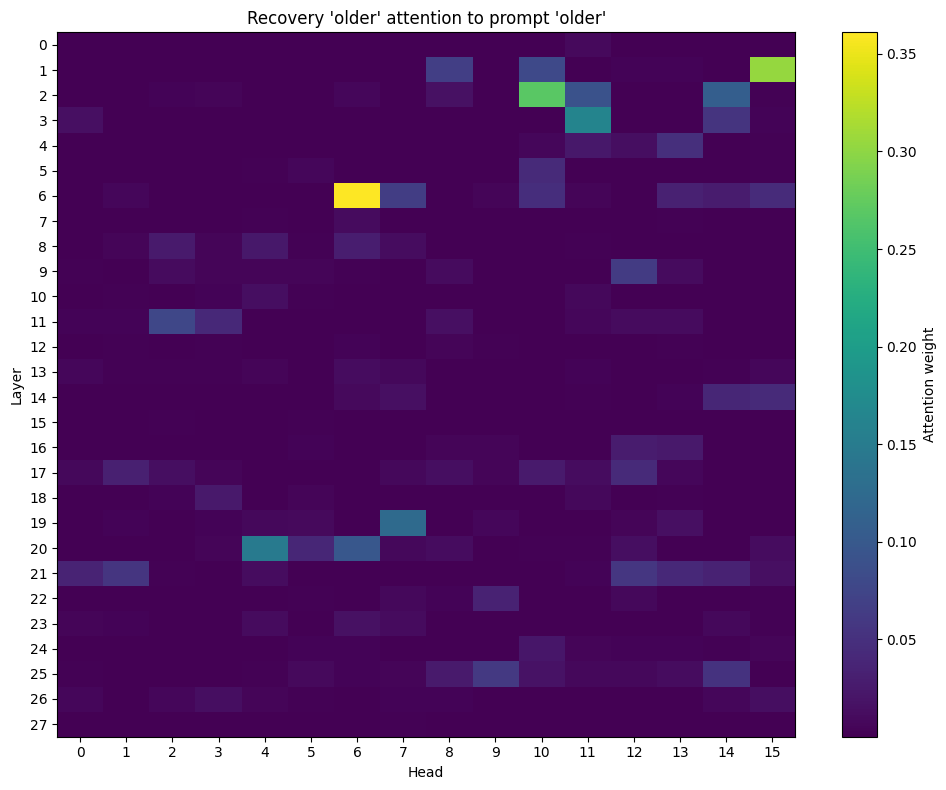

In [10]:
prompt_premise_span = find_token_span(
    counterfactual_ids[:prompt_length], "Alice is older than Bob"
)
prompt_premise_positions = list(range(prompt_premise_span[0], prompt_premise_span[1] + 1))

def word_position(token_ids, span, word):
    matches = [
        position for position in range(span[0], span[1] + 1)
        if tokenizer.decode(token_ids[position:position + 1]).strip() == word
    ]
    assert len(matches) == 1, (word, matches, decoded_span(token_ids, span))
    return matches[0]

prompt_alice_position = word_position(counterfactual_ids, prompt_premise_span, "Alice")
prompt_older_position = word_position(counterfactual_ids, prompt_premise_span, "older")
prompt_bob_position = word_position(counterfactual_ids, prompt_premise_span, "Bob")
recovery_positions = list(range(correct_relation_span[0], correct_relation_span[1] + 1))
recovery_older_position = word_position(counterfactual_ids, correct_relation_span, "older")
forced_counterfactual_span = counterfactual_events["Forced counterfactual end"]["span"]
forced_counterfactual_positions = list(
    range(forced_counterfactual_span[0], forced_counterfactual_span[1] + 1)
)

print("Prompt first premise:")
print(f"  span={prompt_premise_span}, text={decoded_span(counterfactual_ids, prompt_premise_span)!r}")
print(f"  Alice={prompt_alice_position}, older={prompt_older_position}, Bob={prompt_bob_position}")
print("Recovery span:")
print(f"  full span={correct_relation_span}, text={decoded_span(counterfactual_ids, correct_relation_span)!r}")
for position in recovery_positions:
    print(
        f"  generated={position - prompt_length}, full={position}, "
        f"token={tokenizer.decode(counterfactual_ids[position:position + 1])!r}"
    )
print("Forced counterfactual span:")
print(
    f"  full span={forced_counterfactual_span}, "
    f"text={decoded_span(counterfactual_ids, forced_counterfactual_span)!r}"
)

attention_hook_names = [
    f"blocks.{layer}.attn.hook_pattern" for layer in range(tl_model.cfg.n_layers)
]
with torch.inference_mode():
    _, recovery_attention_cache = tl_model.run_with_cache(
        counterfactual_trajectory_ids.to(tl_model.cfg.device),
        names_filter=attention_hook_names,
    )

attention_rows = []
for layer, hook_name in enumerate(attention_hook_names):
    pattern = recovery_attention_cache[hook_name][0].float().cpu()
    for head in range(pattern.shape[0]):
        for recovery_position in recovery_positions:
            attention_rows.append({
                "layer": layer,
                "head": head,
                "recovery_position": recovery_position,
                "generated_position": recovery_position - prompt_length,
                "recovery_token": tokenizer.decode(
                    counterfactual_ids[recovery_position:recovery_position + 1]
                ),
                "prompt_relation_attention": pattern[
                    head, recovery_position, prompt_older_position
                ].item(),
                "prompt_premise_attention": pattern[
                    head, recovery_position, prompt_premise_positions
                ].sum().item(),
                "forced_span_attention": pattern[
                    head, recovery_position, forced_counterfactual_positions
                ].sum().item(),
            })

recovery_attention = pd.DataFrame(attention_rows)
token_attention_summary = recovery_attention.groupby(
    ["generated_position", "recovery_token"], sort=False
).agg(
    mean_prompt_relation=("prompt_relation_attention", "mean"),
    max_prompt_relation=("prompt_relation_attention", "max"),
    mean_prompt_premise=("prompt_premise_attention", "mean"),
    max_prompt_premise=("prompt_premise_attention", "max"),
    mean_forced_span=("forced_span_attention", "mean"),
    max_forced_span=("forced_span_attention", "max"),
).reset_index()
print("\nAttention summary for each recovery token:")
print(token_attention_summary.to_string(index=False, float_format=lambda value: f"{value:.6f}"))

head_summary = recovery_attention.groupby(["layer", "head"]).agg(
    mean_prompt_relation=("prompt_relation_attention", "mean"),
    mean_prompt_premise=("prompt_premise_attention", "mean"),
    mean_forced_span=("forced_span_attention", "mean"),
).reset_index()
strongest_prompt_heads = head_summary.nlargest(20, "mean_prompt_premise")
print("\nStrongest layer/head combinations from the recovery span to the prompt premise:")
print(strongest_prompt_heads.to_string(index=False, float_format=lambda value: f"{value:.6f}"))

relation_attention_heatmap = torch.stack([
    recovery_attention_cache[hook_name][
        0, :, recovery_older_position, prompt_older_position
    ].float().cpu()
    for hook_name in attention_hook_names
]).numpy()
fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(relation_attention_heatmap, aspect="auto", cmap="viridis")
ax.set_xlabel("Head")
ax.set_ylabel("Layer")
ax.set_title("Recovery 'older' attention to prompt 'older'")
ax.set_xticks(range(relation_attention_heatmap.shape[1]))
ax.set_yticks(range(relation_attention_heatmap.shape[0]))
fig.colorbar(image, ax=ax, label="Attention weight")
plt.tight_layout()
plt.show()

## Recovery intervention

Block one candidate head's premise attention during recovery.


In [11]:
RECOVERY_LAYER = 21
RECOVERY_HEAD = 8
RECOVERY_WINDOW_GENERATED = (115, 124)
RECOVERY_GENERATION_SEED = 0
RECOVERY_MAX_NEW_TOKENS = 500

instruction_span = find_token_span(
    counterfactual_ids[:prompt_length],
    "Explain your reasoning and give the final answer",
)
irrelevant_prompt_positions = list(range(instruction_span[0], instruction_span[0] + 5))
assert len(irrelevant_prompt_positions) == len(prompt_premise_positions) == 5
assert not set(irrelevant_prompt_positions) & set(prompt_premise_positions)

counterfactual_forced_ids = tokenizer(
    forced_statements["Counterfactual"],
    return_tensors="pt",
    add_special_tokens=False,
)["input_ids"].to(fixed_prefix_ids.device)
recovery_generation_input = torch.cat(
    [fixed_prefix_ids, counterfactual_forced_ids], dim=1
).to(tl_model.cfg.device)
assert recovery_generation_input.shape[1] == forced_counterfactual_span[1] + 1

recovery_conditions = {
    "Baseline": None,
    "Premise-attention block": prompt_premise_positions,
    "Relation-token-only block": [prompt_older_position],
    "Irrelevant-token control": irrelevant_prompt_positions,
}
recovery_hook_name = f"blocks.{RECOVERY_LAYER}.attn.hook_pattern"
window_start_full = prompt_length + RECOVERY_WINDOW_GENERATED[0]
window_end_full = prompt_length + RECOVERY_WINDOW_GENERATED[1]
expected_query_positions = list(range(window_start_full, window_end_full + 1))

def generate_with_recovery_attention_block(blocked_key_positions):
    torch.manual_seed(RECOVERY_GENERATION_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(RECOVERY_GENERATION_SEED)

    generation_kwargs = dict(
        max_new_tokens=RECOVERY_MAX_NEW_TOKENS,
        do_sample=False,
        use_past_kv_cache=True,
        prepend_bos=False,
        return_type="tokens",
        verbose=False,
    )
    if blocked_key_positions is None:
        return tl_model.generate(recovery_generation_input, **generation_kwargs), None

    tracker = {
        "query_positions": [],
        "max_blocked_weight": 0.0,
        "max_sum_error": 0.0,
    }

    def block_selected_attention(pattern, hook):
        if pattern.shape[2] != 1:
            return pattern
        query_position = pattern.shape[-1] - 1
        if not window_start_full <= query_position <= window_end_full:
            return pattern

        before = pattern
        patched = pattern.clone()
        original_row = before[0, RECOVERY_HEAD, 0].clone()
        patched_row = patched[0, RECOVERY_HEAD, 0]
        patched_row[blocked_key_positions] = 0.0
        remaining_mass = patched_row.sum()
        assert remaining_mass > 0
        patched_row /= remaining_mass

        other_heads = [head for head in range(pattern.shape[1]) if head != RECOVERY_HEAD]
        assert torch.equal(patched[0, other_heads], before[0, other_heads])
        assert torch.count_nonzero(patched_row[blocked_key_positions]).item() == 0
        assert torch.allclose(patched_row.sum(), torch.ones((), device=patched.device), atol=1e-6)
        unblocked = torch.ones_like(original_row, dtype=torch.bool)
        unblocked[blocked_key_positions] = False
        positive = unblocked & (original_row > 1e-12)
        ratios = patched_row[positive] / original_row[positive]
        assert torch.allclose(ratios, torch.full_like(ratios, ratios[0]), rtol=1e-4, atol=1e-6)

        tracker["query_positions"].append(query_position)
        tracker["max_blocked_weight"] = max(
            tracker["max_blocked_weight"],
            patched_row[blocked_key_positions].abs().max().item(),
        )
        tracker["max_sum_error"] = max(
            tracker["max_sum_error"], abs(patched_row.sum().item() - 1.0)
        )
        return patched

    with tl_model.hooks(fwd_hooks=[(recovery_hook_name, block_selected_attention)]):
        generated = tl_model.generate(recovery_generation_input, **generation_kwargs)
    assert tracker["query_positions"] == expected_query_positions
    assert tracker["max_blocked_weight"] == 0.0
    assert tracker["max_sum_error"] < 1e-6
    return generated, tracker

def summarize_recovery_generation(generated_tokens):
    generated_start = prompt_length
    full_text = tl_model.to_string(generated_tokens[0, generated_start:])
    excerpt_start = prompt_length + RECOVERY_WINDOW_GENERATED[0]
    excerpt_end = min(generated_tokens.shape[1], excerpt_start + 55)
    recovery_excerpt = tl_model.to_string(generated_tokens[0, excerpt_start:excerpt_end])
    post_window_text = tl_model.to_string(generated_tokens[0, window_start_full:])
    correct_relation_forms = [
        "Alice is older than Bob",
        "Alice > Bob",
        "Bob is younger than Alice",
    ]
    bob_oldest_forms = ["Bob is the oldest", "Bob would be the oldest"]
    recovered_correct_relation = any(form in post_window_text for form in correct_relation_forms)
    bob_treated_as_oldest_after_window = any(form in post_window_text for form in bob_oldest_forms)
    final_answer = (
        full_text.split("</think>", 1)[1].replace("<|im_end|>", "").strip()
        if "</think>" in full_text
        else "[no final answer generated]"
    )
    return {
        "recovery_excerpt": recovery_excerpt,
        "recovered_correct_relation": recovered_correct_relation,
        "bob_treated_as_oldest_after_window": bob_treated_as_oldest_after_window,
        "final_answer": final_answer,
        "full_text": full_text,
    }

recovery_intervention_results = []
for condition, blocked_positions in recovery_conditions.items():
    generated_tokens, tracker = generate_with_recovery_attention_block(blocked_positions)
    summary = summarize_recovery_generation(generated_tokens)
    summary.update({
        "condition": condition,
        "blocked_positions": blocked_positions,
        "tracker": tracker,
    })
    recovery_intervention_results.append(summary)

print(f"Layer={RECOVERY_LAYER}, head={RECOVERY_HEAD}, recovery window={RECOVERY_WINDOW_GENERATED}")
print(
    f"Premise positions={prompt_premise_positions}, relation position={prompt_older_position}, "
    f"irrelevant control positions={irrelevant_prompt_positions}"
)
for result in recovery_intervention_results:
    print(f"\n=== {result['condition']} ===")
    print(f"Blocked prompt positions: {result['blocked_positions']}")
    print("Reasoning around recovery:")
    print(result["recovery_excerpt"])
    print(f"Recovered correct relation: {result['recovered_correct_relation']}")
    print(f"Bob treated as oldest after window: {result['bob_treated_as_oldest_after_window']}")
    print("Final answer:")
    print(result["final_answer"])
    if not result["recovered_correct_relation"] or result["bob_treated_as_oldest_after_window"]:
        print("Full continuation:")
        print(result["full_text"])

Layer=21, head=8, recovery window=(115, 124)
Premise positions=[3, 4, 5, 6, 7], relation position=5, irrelevant control positions=[20, 21, 22, 23, 24]

=== Baseline ===
Blocked prompt positions: None
Reasoning around recovery:
 again.

The problem states Alice is older than Bob, which would mean Alice is older than Bob. Then Bob is older than Charlie. So the order is Alice > Bob > Charlie. Therefore, Alice is the oldest. But wait, is there a possibility that Charlie is older
Recovered correct relation: True
Bob treated as oldest after window: False
Final answer:
Since Alice is older than Bob and Bob is older than Charlie, the order of their ages is Alice > Bob > Charlie. Therefore, **Alice is the oldest**.

**Final Answer:** Alice.

=== Premise-attention block ===
Blocked prompt positions: [3, 4, 5, 6, 7]
Reasoning around recovery:
 again.

The problem states Alice is older than Bob, which would mean Alice is older than Bob. Then Bob is older than Charlie. So the order is Alice > Bob >

## Recovery localization

Test whether a valid position-matched recovery comparison can be constructed.


In [12]:
LOCALIZATION_SEED = 0
LOCALIZATION_MAX_NEW_TOKENS = 500

recovery_prefix_ids = counterfactual_trajectory_ids[:, :correct_relation_span[0]].clone()
recovered_event_ids = counterfactual_trajectory_ids[:, correct_relation_span[0]:correct_relation_span[1] + 1].clone()
bob_event_ids = tokenizer(
    " Bob is older than Alice", return_tensors="pt", add_special_tokens=False
)["input_ids"].to(recovery_prefix_ids.device)
assert recovered_event_ids.shape == bob_event_ids.shape == (1, 5)
assert tokenizer.decode(recovered_event_ids[0]) == " Alice is older than Bob"
assert tokenizer.decode(bob_event_ids[0]) == " Bob is older than Alice"
assert recovered_event_ids[0, 2].item() == bob_event_ids[0, 2].item()
assert tokenizer.decode(recovered_event_ids[0, 2:3]).strip() == "older"

recovered_input_ids = torch.cat([recovery_prefix_ids, recovered_event_ids], dim=1).to(tl_model.cfg.device)
bob_input_ids = torch.cat([recovery_prefix_ids, bob_event_ids], dim=1).to(tl_model.cfg.device)
recovery_relation_position = recovery_prefix_ids.shape[1] + 2
adjacent_position = recovery_relation_position + 1
assert tokenizer.decode(recovered_input_ids[0, recovery_relation_position:recovery_relation_position + 1]).strip() == "older"
assert tokenizer.decode(recovered_input_ids[0, adjacent_position:adjacent_position + 1]).strip() == "than"

def greedy_completion(input_ids, hook=None):
    torch.manual_seed(LOCALIZATION_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(LOCALIZATION_SEED)
    kwargs = dict(
        max_new_tokens=LOCALIZATION_MAX_NEW_TOKENS,
        do_sample=False,
        use_past_kv_cache=True,
        prepend_bos=False,
        return_type="tokens",
        verbose=False,
    )
    if hook is None:
        return tl_model.generate(input_ids, **kwargs)
    with tl_model.hooks(fwd_hooks=[hook]):
        return tl_model.generate(input_ids, **kwargs)

def completion_metrics(tokens, forced_input_length):
    full_text = tl_model.to_string(tokens[0, prompt_length:])
    downstream_text = tl_model.to_string(tokens[0, forced_input_length:])
    correct_forms = ["Alice is older than Bob", "Alice > Bob", "Bob is younger than Alice"]
    bob_forms = ["Bob is the oldest", "Bob would be the oldest"]
    recovered = any(form in downstream_text for form in correct_forms)
    bob_consistent = any(form in downstream_text for form in bob_forms) and not recovered
    think_token = tl_model.to_single_token("</think>")
    think_positions = (tokens[0] == think_token).nonzero(as_tuple=False).flatten().tolist()
    answer_start = think_positions[-1] + 1 if think_positions else forced_input_length
    answer_positions = [
        position for position in range(answer_start, tokens.shape[1])
        if tokens[0, position].item() in (tl_alice_token_id, tl_bob_token_id)
    ]
    assert answer_positions, "No Alice/Bob token found in final answer"
    answer_token_position = answer_positions[-1]
    readout_position = answer_token_position - 1
    with torch.inference_mode():
        logits = tl_model(tokens)
    D = (
        logits[0, readout_position, tl_alice_token_id]
        - logits[0, readout_position, tl_bob_token_id]
    ).item()
    final_answer = tl_model.to_string(tokens[0, answer_start:]).replace("<|im_end|>", "").strip()
    return {
        "D": D,
        "readout_position": readout_position,
        "answer_token": tl_model.to_string(tokens[0, answer_token_position]),
        "recovered": recovered,
        "bob_consistent": bob_consistent,
        "final_answer": final_answer,
        "full_text": full_text,
    }

recovered_baseline_tokens = greedy_completion(recovered_input_ids)
bob_baseline_tokens = greedy_completion(bob_input_ids)
recovered_baseline = completion_metrics(recovered_baseline_tokens, recovered_input_ids.shape[1])
bob_baseline = completion_metrics(bob_baseline_tokens, bob_input_ids.shape[1])
comparison_valid = (
    recovered_baseline["answer_token"].strip() == "Alice"
    and recovered_baseline["recovered"]
    and bob_baseline["answer_token"].strip() == "Bob"
    and bob_baseline["bob_consistent"]
)
print("Recovered baseline final answer:", recovered_baseline["final_answer"])
print("Bob-comparison final answer:", bob_baseline["final_answer"])
print("Position-matched Bob-consistent comparison valid:", comparison_valid)

if not comparison_valid:
    print("Layer scan stopped: the equal-length comparison did not remain Bob-consistent.")
else:
    residual_hook_names = [
        f"blocks.{layer}.hook_resid_post" for layer in range(tl_model.cfg.n_layers)
    ]
    with torch.inference_mode():
        recovered_logits, recovered_localization_cache = tl_model.run_with_cache(
            recovered_baseline_tokens, names_filter=residual_hook_names
        )
        bob_logits, bob_localization_cache = tl_model.run_with_cache(
            bob_baseline_tokens, names_filter=residual_hook_names
        )

    def fixed_readout_D(logits, metrics):
        position = metrics["readout_position"]
        return (logits[0, position, tl_alice_token_id] - logits[0, position, tl_bob_token_id]).item()

    recovered_baseline_D = fixed_readout_D(recovered_logits, recovered_baseline)
    bob_baseline_D = fixed_readout_D(bob_logits, bob_baseline)

    def teacher_forced_patch(base_tokens, source_cache, hook_name, source_position, target_position):
        source_vector = source_cache[hook_name][0, source_position].detach().clone()
        def patch_residual(activation, hook):
            patched = activation.clone()
            patched[0, target_position] = source_vector
            return patched
        return tl_model.run_with_hooks(base_tokens, fwd_hooks=[(hook_name, patch_residual)])

    def free_generation_patch(base_input, source_cache, hook_name, source_position, target_position):
        source_vector = source_cache[hook_name][0, source_position].detach().clone()
        patch_count = {"value": 0}
        def patch_prefill(activation, hook):
            if activation.shape[1] == base_input.shape[1]:
                patched = activation.clone()
                patched[0, target_position] = source_vector
                patch_count["value"] += 1
                return patched
            return activation
        generated = greedy_completion(base_input, hook=(hook_name, patch_prefill))
        assert patch_count["value"] == 1
        return generated

    localization_rows = []
    identity_errors = []
    for layer, hook_name in enumerate(residual_hook_names):
        recovered_to_bob_logits = teacher_forced_patch(
            bob_baseline_tokens, recovered_localization_cache, hook_name,
            recovery_relation_position, recovery_relation_position,
        )
        bob_to_recovered_logits = teacher_forced_patch(
            recovered_baseline_tokens, bob_localization_cache, hook_name,
            recovery_relation_position, recovery_relation_position,
        )
        adjacent_logits = teacher_forced_patch(
            bob_baseline_tokens, recovered_localization_cache, hook_name,
            adjacent_position, adjacent_position,
        )
        recovered_identity_logits = teacher_forced_patch(
            recovered_baseline_tokens, recovered_localization_cache, hook_name,
            recovery_relation_position, recovery_relation_position,
        )
        bob_identity_logits = teacher_forced_patch(
            bob_baseline_tokens, bob_localization_cache, hook_name,
            recovery_relation_position, recovery_relation_position,
        )
        identity_errors.extend([
            abs(fixed_readout_D(recovered_identity_logits, recovered_baseline) - recovered_baseline_D),
            abs(fixed_readout_D(bob_identity_logits, bob_baseline) - bob_baseline_D),
        ])

        recovered_to_bob_tokens = free_generation_patch(
            bob_input_ids, recovered_localization_cache, hook_name,
            recovery_relation_position, recovery_relation_position,
        )
        bob_to_recovered_tokens = free_generation_patch(
            recovered_input_ids, bob_localization_cache, hook_name,
            recovery_relation_position, recovery_relation_position,
        )
        recovered_to_bob_metrics = completion_metrics(
            recovered_to_bob_tokens, bob_input_ids.shape[1]
        )
        bob_to_recovered_metrics = completion_metrics(
            bob_to_recovered_tokens, recovered_input_ids.shape[1]
        )

        localization_rows.extend([
            {
                "layer": layer, "direction": "recovered_to_bob",
                "D_teacher_forced": fixed_readout_D(recovered_to_bob_logits, bob_baseline),
                "D_baseline": bob_baseline_D,
                "recovered_in_generation": recovered_to_bob_metrics["recovered"],
                "final_answer": recovered_to_bob_metrics["answer_token"].strip(),
            },
            {
                "layer": layer, "direction": "bob_to_recovered",
                "D_teacher_forced": fixed_readout_D(bob_to_recovered_logits, recovered_baseline),
                "D_baseline": recovered_baseline_D,
                "recovered_in_generation": bob_to_recovered_metrics["recovered"],
                "final_answer": bob_to_recovered_metrics["answer_token"].strip(),
            },
            {
                "layer": layer, "direction": "adjacent_than_control",
                "D_teacher_forced": fixed_readout_D(adjacent_logits, bob_baseline),
                "D_baseline": bob_baseline_D,
                "recovered_in_generation": None, "final_answer": None,
            },
        ])

    recovery_localization_results = pd.DataFrame(localization_rows)
    recovery_localization_results["DeltaD"] = (
        recovery_localization_results["D_teacher_forced"]
        - recovery_localization_results["D_baseline"]
    )
    identity_tolerance = 1e-4
    print(f"Max identity-patch |DeltaD|: {max(identity_errors):.3e}")
    assert max(identity_errors) < identity_tolerance
    print(recovery_localization_results.to_string(index=False, float_format=lambda value: f"{value:.6f}"))

Recovered baseline final answer: Since Alice is older than Bob and Bob is older than Charlie, the order of their ages is Alice > Bob > Charlie. Therefore, **Alice is the oldest**.

**Final Answer:** Alice.
Bob-comparison final answer: To determine who is the oldest among Alice, Bob, and Charlie, we analyze the given relationships:

1. **Alice is older than Bob** → Alice > Bob  
2. **Bob is older than Charlie** → Bob > Charlie  

Combining these two, the hierarchy from oldest to youngest becomes:  
**Alice > Bob > Charlie**

Therefore, the **oldest** individual is **Alice**.

**Final Answer:** Alice.
Position-matched Bob-consistent comparison valid: False
Layer scan stopped: the equal-length comparison did not remain Bob-consistent.


## Recovery versus persistent error

Compare semantically aligned states without patching between mismatched trajectories.


In [13]:
PERSISTENT_BOB_LAYER = 3
persistent_result = next(
    result for result in prompt_intervention_generations
    if result["condition"] == "patched clean prompt" and result["layer"] == PERSISTENT_BOB_LAYER
)
persistent_completion_ids = tokenizer(
    persistent_result["text"], return_tensors="pt", add_special_tokens=False
)["input_ids"].to(clean_generation_tokens.device)
persistent_bob_ids = torch.cat([clean_generation_tokens, persistent_completion_ids], dim=1)
recovered_alice_ids = counterfactual_trajectory_ids.to(persistent_bob_ids.device)
assert torch.equal(recovered_alice_ids[0, :prompt_length], persistent_bob_ids[0, :prompt_length])
assert tl_model.to_string(persistent_bob_ids[0, prompt_length:]) == persistent_result["text"]

recovered_first_relation = find_token_span(
    recovered_alice_ids[0], " Alice is older than Bob, and Bob is older than Charlie",
    start=prompt_length,
)
recovered_integrated = forced_counterfactual_span
recovered_restatement = correct_relation_span
recovered_conclusion = find_token_span(
    recovered_alice_ids[0], " Alice is the oldest", start=recovered_restatement[1] + 1
)
recovered_final = counterfactual_final_span

persistent_first_relation = find_token_span(
    persistent_bob_ids[0], " Alice is younger than Bob", start=prompt_length
)
persistent_integrated = find_token_span(
    persistent_bob_ids[0], " Bob is older than both Alice and Charlie",
    start=persistent_first_relation[1] + 1,
)
persistent_restatement = find_token_span(
    persistent_bob_ids[0], " Alice is younger than Bob",
    start=persistent_integrated[1] + 1,
)
persistent_conclusion = find_token_span(
    persistent_bob_ids[0], " Bob is the oldest", start=persistent_restatement[1] + 1
)
persistent_final_marker = "**Final Answer:** Bob"
persistent_final = find_token_span(persistent_bob_ids[0], persistent_final_marker, last=True)
persistent_marker_ids = tokenizer(
    persistent_final_marker, add_special_tokens=False
)["input_ids"]
persistent_bob_offsets = [
    index for index, token_id in enumerate(persistent_marker_ids) if token_id == tl_bob_token_id
]
assert persistent_bob_offsets
persistent_final_readout = persistent_final[0] + persistent_bob_offsets[-1] - 1

semantic_events = {
    "First relation statement": {
        "recovered_span": recovered_first_relation,
        "persistent_span": persistent_first_relation,
        "alignment": "valid: first reasoning statement of the Alice/Bob premise",
    },
    "Integrated ordering": {
        "recovered_span": recovered_integrated,
        "persistent_span": persistent_integrated,
        "alignment": "valid: first integrated Bob-directed ordering/conclusion",
    },
    "Relation restatement": {
        "recovered_span": recovered_restatement,
        "persistent_span": persistent_restatement,
        "alignment": "approximate: correction in A versus later premise reiteration in B",
    },
    "Oldest-person conclusion": {
        "recovered_span": recovered_conclusion,
        "persistent_span": persistent_conclusion,
        "alignment": "valid: first oldest-person conclusion after the aligned restatement",
    },
    "Final-answer readout": {
        "recovered_span": recovered_final,
        "persistent_span": persistent_final,
        "recovered_position": counterfactual_final_readout,
        "persistent_position": persistent_final_readout,
        "alignment": "valid: actual final-answer readout before Alice/Bob",
    },
}
for event in semantic_events.values():
    event.setdefault("recovered_position", event["recovered_span"][1])
    event.setdefault("persistent_position", event["persistent_span"][1])

for event_name, event in semantic_events.items():
    print(f"\n{event_name}")
    print("Alignment:", event["alignment"])
    print(
        f"Recovered A: full={event['recovered_position']}, "
        f"generated={event['recovered_position'] - prompt_length}, "
        f"span={event['recovered_span']}, "
        f"text={decoded_span(recovered_alice_ids[0], event['recovered_span'])!r}"
    )
    print("  context:", surrounding_text(recovered_alice_ids[0], event["recovered_position"]))
    print(
        f"Persistent B: full={event['persistent_position']}, "
        f"generated={event['persistent_position'] - prompt_length}, "
        f"span={event['persistent_span']}, "
        f"text={decoded_span(persistent_bob_ids[0], event['persistent_span'])!r}"
    )
    print("  context:", surrounding_text(persistent_bob_ids[0], event["persistent_position"]))

comparison_hook_names = [
    f"blocks.{layer}.hook_resid_post" for layer in range(tl_model.cfg.n_layers)
]
with torch.inference_mode():
    recovered_comparison_logits, recovered_comparison_cache = tl_model.run_with_cache(
        recovered_alice_ids.to(tl_model.cfg.device), names_filter=comparison_hook_names
    )
    persistent_comparison_logits, persistent_comparison_cache = tl_model.run_with_cache(
        persistent_bob_ids.to(tl_model.cfg.device), names_filter=comparison_hook_names
    )

comparison_rows = []
for event_name, event in semantic_events.items():
    for layer, hook_name in enumerate(comparison_hook_names):
        recovered_state = recovered_comparison_cache[hook_name][0, event["recovered_position"]].float()
        persistent_state = persistent_comparison_cache[hook_name][0, event["persistent_position"]].float()
        comparison_rows.append({
            "event": event_name,
            "layer": layer,
            "cosine_similarity": F.cosine_similarity(
                recovered_state, persistent_state, dim=0
            ).item(),
            "recovered_norm": recovered_state.norm().item(),
            "persistent_norm": persistent_state.norm().item(),
        })
comparison_results = pd.DataFrame(comparison_rows)
comparison_cosines = comparison_results.pivot(
    index="event", columns="layer", values="cosine_similarity"
).loc[list(semantic_events)]
recovered_norms_by_event = comparison_results.pivot(
    index="event", columns="layer", values="recovered_norm"
).loc[list(semantic_events)]
persistent_norms_by_event = comparison_results.pivot(
    index="event", columns="layer", values="persistent_norm"
).loc[list(semantic_events)]

def layerwise_final_readout(cache, readout_position):
    values = []
    for layer, hook_name in enumerate(comparison_hook_names):
        state = cache[hook_name][0, readout_position]
        layer_logits = tl_model.unembed(tl_model.ln_final(state))
        values.append((layer_logits[tl_alice_token_id] - layer_logits[tl_bob_token_id]).item())
    return values

final_readout_table = pd.DataFrame({
    "layer": range(tl_model.cfg.n_layers),
    "recovered_A_D": layerwise_final_readout(
        recovered_comparison_cache, counterfactual_final_readout
    ),
    "persistent_B_D": layerwise_final_readout(
        persistent_comparison_cache, persistent_final_readout
    ),
})
actual_recovered_D = (
    recovered_comparison_logits[0, counterfactual_final_readout, tl_alice_token_id]
    - recovered_comparison_logits[0, counterfactual_final_readout, tl_bob_token_id]
).item()
actual_persistent_D = (
    persistent_comparison_logits[0, persistent_final_readout, tl_alice_token_id]
    - persistent_comparison_logits[0, persistent_final_readout, tl_bob_token_id]
).item()

print("\nCosine similarity by layer (diagnostic only):")
print(comparison_cosines.to_string(float_format=lambda value: f"{value:.4f}"))
print("\nRecovered-Alice residual norms:")
print(recovered_norms_by_event.to_string(float_format=lambda value: f"{value:.4f}"))
print("\nPersistent-Bob residual norms:")
print(persistent_norms_by_event.to_string(float_format=lambda value: f"{value:.4f}"))
print("\nLayerwise Alice-Bob readout at each trajectory's actual final-answer context:")
print(final_readout_table.to_string(index=False, float_format=lambda value: f"{value:.6f}"))
print(f"\nActual final D: recovered A={actual_recovered_D:.6f}, persistent B={actual_persistent_D:.6f}")


First relation statement
Alignment: valid: first reasoning statement of the Alice/Bob premise
Recovered A: full=57, generated=22, span=(46, 57), text=' Alice is older than Bob, and Bob is older than Charlie'
  context:  is older than Bob, and Bob is older than Charlie. I need to figure out who is the oldest
Persistent B: full=50, generated=15, span=(46, 50), text=' Alice is younger than Bob'
  context: 's see. The problem says Alice is younger than Bob, and Bob is older than Charlie. I need

Integrated ordering
Alignment: valid: first integrated Bob-directed ordering/conclusion
Recovered A: full=93, generated=58, span=(86, 93), text=' Bob > Alice, and Bob > Charlie'
  context: .

So, Bob > Alice, and Bob > Charlie. That means Bob is older than both Alice and
Persistent B: full=118, generated=83, span=(111, 118), text=' Bob is older than both Alice and Charlie'
  context: , so if Bob is older than both Alice and Charlie, then Bob is the oldest. But wait,

Relation restatement
Alignment

## Position-matched relation probe

Hold all visible text fixed and causally compare clean and corrupted prompt states at one relation probe.


Probe position: 50
Controlled text: '<think>\nBob is older than Alice. Reconsider the original premises. Alice is'
Condition A (normal clean prompt state):
  logit(' older')=24.809601
  logit(' younger')=19.577734
  D=5.231867
Condition B (layer-3 corrupted prompt state):
  logit(' older')=21.913218
  logit(' younger')=25.417542
  D=-3.504324

Position-matched state diagnostics:
 layer  cosine_similarity     norm_A     norm_B  lens_D_A  lens_D_B
     0           1.000000   7.015210   7.015210 -0.087915 -0.087915
     1           1.000000   8.918566   8.918566  2.315586  2.315586
     2           1.000000  11.279160  11.279160  1.605554  1.605554
     3           1.000000  13.943371  13.943371 -0.700679 -0.700679
     4           0.999998  16.366106  16.365255 -1.515550 -1.516685
     5           0.999996  18.687578  18.690466 -0.066508 -0.079915
     6           0.999532  19.260904  19.199894  0.982509  0.889140
     7           0.999677  21.229614  21.171347  0.741884  0.722969
     8

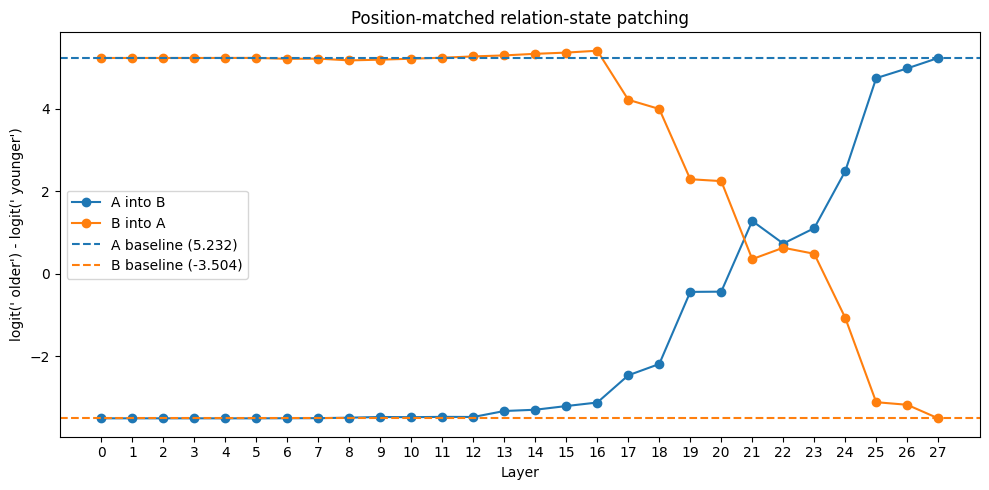

In [14]:
PROMPT_INTERVENTION_LAYER = 3
controlled_continuation = (
    "<think>\nBob is older than Alice. "
    "Reconsider the original premises. Alice is"
)
controlled_continuation_ids = tokenizer(
    controlled_continuation, return_tensors="pt", add_special_tokens=False
)["input_ids"].to(clean_generation_tokens.device)
relation_probe_tokens = torch.cat(
    [clean_generation_tokens, controlled_continuation_ids], dim=1
).to(tl_model.cfg.device)
probe_position = relation_probe_tokens.shape[1] - 1
assert tokenizer.decode(relation_probe_tokens[0, probe_position:probe_position + 1]) == " is"

older_token_id = tl_model.to_single_token(" older")
younger_token_id = tl_model.to_single_token(" younger")
prompt_intervention_hook = f"blocks.{PROMPT_INTERVENTION_LAYER}.hook_resid_post"
corrupted_prompt_vector = corrupt_prompt_cache[prompt_intervention_hook][
    0, generation_relation_position
].detach().clone()
all_probe_hooks = [
    f"blocks.{layer}.hook_resid_post" for layer in range(tl_model.cfg.n_layers)
]

def make_prompt_state_hook():
    tracker = {"count": 0}
    def patch_prompt_state(activation, hook):
        patched = activation.clone()
        patched[0, generation_relation_position] = corrupted_prompt_vector
        changed_positions = (
            (patched[0] - activation[0]).abs().sum(dim=-1) > 0
        ).nonzero(as_tuple=False).flatten().tolist()
        assert changed_positions == [generation_relation_position]
        tracker["count"] += 1
        return patched
    return patch_prompt_state, tracker

with torch.inference_mode():
    condition_A_logits, condition_A_cache = tl_model.run_with_cache(
        relation_probe_tokens, names_filter=all_probe_hooks
    )
prompt_state_hook, prompt_state_tracker = make_prompt_state_hook()
with torch.inference_mode(), tl_model.hooks(
    fwd_hooks=[(prompt_intervention_hook, prompt_state_hook)]
):
    condition_B_logits, condition_B_cache = tl_model.run_with_cache(
        relation_probe_tokens, names_filter=all_probe_hooks
    )
assert prompt_state_tracker["count"] == 1

def relation_logit_difference(logits):
    return (
        logits[0, probe_position, older_token_id]
        - logits[0, probe_position, younger_token_id]
    ).item()

condition_A_older = condition_A_logits[0, probe_position, older_token_id].item()
condition_A_younger = condition_A_logits[0, probe_position, younger_token_id].item()
condition_B_older = condition_B_logits[0, probe_position, older_token_id].item()
condition_B_younger = condition_B_logits[0, probe_position, younger_token_id].item()
condition_A_D = relation_logit_difference(condition_A_logits)
condition_B_D = relation_logit_difference(condition_B_logits)

probe_diagnostic_rows = []
for layer, hook_name in enumerate(all_probe_hooks):
    state_A = condition_A_cache[hook_name][0, probe_position].float()
    state_B = condition_B_cache[hook_name][0, probe_position].float()
    lens_A = tl_model.unembed(tl_model.ln_final(state_A))
    lens_B = tl_model.unembed(tl_model.ln_final(state_B))
    probe_diagnostic_rows.append({
        "layer": layer,
        "cosine_similarity": F.cosine_similarity(state_A, state_B, dim=0).item(),
        "norm_A": state_A.norm().item(),
        "norm_B": state_B.norm().item(),
        "lens_D_A": (lens_A[older_token_id] - lens_A[younger_token_id]).item(),
        "lens_D_B": (lens_B[older_token_id] - lens_B[younger_token_id]).item(),
    })
probe_diagnostics = pd.DataFrame(probe_diagnostic_rows)

def run_probe_patch(base_condition, source_cache, hook_name):
    source_vector = source_cache[hook_name][0, probe_position].detach().clone()
    patch_count = {"value": 0}
    def patch_probe(activation, hook):
        patched = activation.clone()
        patched[0, probe_position] = source_vector
        patch_count["value"] += 1
        return patched

    hooks = [(hook_name, patch_probe)]
    prompt_tracker = None
    if base_condition == "B":
        prompt_hook, prompt_tracker = make_prompt_state_hook()
        hooks.insert(0, (prompt_intervention_hook, prompt_hook))
    with torch.inference_mode(), tl_model.hooks(fwd_hooks=hooks):
        logits = tl_model(relation_probe_tokens)
    assert patch_count["value"] == 1
    if prompt_tracker is not None:
        assert prompt_tracker["count"] == 1
    return relation_logit_difference(logits)

probe_patch_rows = []
for layer, hook_name in enumerate(all_probe_hooks):
    A_to_B = run_probe_patch("B", condition_A_cache, hook_name)
    B_to_A = run_probe_patch("A", condition_B_cache, hook_name)
    A_to_A = run_probe_patch("A", condition_A_cache, hook_name)
    B_to_B = run_probe_patch("B", condition_B_cache, hook_name)
    probe_patch_rows.append({
        "layer": layer,
        "A_to_B_D": A_to_B,
        "A_to_B_DeltaD": A_to_B - condition_B_D,
        "B_to_A_D": B_to_A,
        "B_to_A_DeltaD": B_to_A - condition_A_D,
        "A_identity_error": A_to_A - condition_A_D,
        "B_identity_error": B_to_B - condition_B_D,
    })
probe_patch_results = pd.DataFrame(probe_patch_rows)
identity_error = max(
    probe_patch_results["A_identity_error"].abs().max(),
    probe_patch_results["B_identity_error"].abs().max(),
)
identity_tolerance = 1e-6 + 5e-5 * max(abs(condition_A_D), abs(condition_B_D), 1.0)
assert identity_error < identity_tolerance

print(f"Probe position: {probe_position}")
print(f"Controlled text: {controlled_continuation!r}")
print("Condition A (normal clean prompt state):")
print(f"  logit(' older')={condition_A_older:.6f}")
print(f"  logit(' younger')={condition_A_younger:.6f}")
print(f"  D={condition_A_D:.6f}")
print("Condition B (layer-3 corrupted prompt state):")
print(f"  logit(' older')={condition_B_older:.6f}")
print(f"  logit(' younger')={condition_B_younger:.6f}")
print(f"  D={condition_B_D:.6f}")
print("\nPosition-matched state diagnostics:")
print(probe_diagnostics.to_string(index=False, float_format=lambda value: f"{value:.6f}"))
print("\nSame-position residual patching:")
print(probe_patch_results.to_string(index=False, float_format=lambda value: f"{value:.6f}"))
print(f"\nMax identity-patch error: {identity_error:.3e}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(probe_patch_results["layer"], probe_patch_results["A_to_B_D"], marker="o", label="A (clean state) → B")
ax.plot(probe_patch_results["layer"], probe_patch_results["B_to_A_D"], marker="o", label="B (corrupted state) → A")
ax.axhline(condition_A_D, color="tab:blue", linestyle="--", label=f"A baseline ({condition_A_D:.3f})")
ax.axhline(condition_B_D, color="tab:orange", linestyle="--", label=f"B baseline ({condition_B_D:.3f})")
ax.set_xticks(range(tl_model.cfg.n_layers))
ax.set_xlabel("Patched layer")
ax.set_ylabel("logit(' older') - logit(' younger')")
ax.set_title("Position-matched relation-state patching")
ax.legend()
plt.tight_layout()

from pathlib import Path
figure_dir = Path.cwd().parent / "figures" if Path.cwd().name == "notebooks" else Path.cwd() / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_dir / "position-matched-relation-patching.png", dpi=250, bbox_inches="tight")
plt.show()